<a href="https://colab.research.google.com/github/Srinvitha/devtown-ml-bootcamp/blob/main/MACHINE_LEARNING_MASTERY_%E2%80%93_COMPARE%2C_CHOOSE_%26_BUILD_BOOTCAMP_DEVTOWN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DAY 1

In [ ]:
#Regression
#Prediciting price when area is given
from sklearn.linear_model import LinearRegression
area=[[500],[700],[800],[2200]]
price=[5,9,17,30]

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(area,price)

LinearRegression()

In [ ]:
prediction=model.predict([[1600]])
print("Predicted price: ", prediction)

Predicted price:  [22.64917127]


In [ ]:
#Classification
#Predict pass or fail
from sklearn.linear_model import LogisticRegression

In [ ]:
hours=[[2],[3],[4],[5],[6]]
result=[0,0,1,1,1]
model=LogisticRegression()

In [ ]:
model.fit(hours,result)

LogisticRegression()

In [ ]:
prediction=model.predict([[1]])
print("Predicted result: ", prediction)

Predicted result:  [0]


In [ ]:
# K - means Clustering
from sklearn.cluster import KMeans
data=[[1,2],[2,3],[3,6],[10,12]]

In [ ]:
model=KMeans(n_clusters=3) # MINI TASK 2
model.fit(data)

KMeans(n_clusters=3)

In [ ]:
print(model.labels_)

[0 0 2 1]


In [ ]:
#Regression MINI TASK 1
#Creating own regression dataset: ex: Temp -> Ice Cream Sales
from sklearn.linear_model import LinearRegression
temp=[[40],[37],[28],[32]]
price=[22,18,7,12]
model=LinearRegression()
model.fit(area,price)
prediction=model.predict([[35]])
print("Predicted price: ", prediction)

Predicted price:  [18.3109116]


## DAY 2

In [2]:
# Predict the no. of hours the battery will last based on the battery capacity (Linear Regression)
from sklearn.linear_model import LinearRegression
battery = [[2000], [3000], [7000], [9000]]
backup = [8, 12, 16, 20]
model = LinearRegression()
model.fit(battery, backup)
prediction = model.predict([[8000]])
print(prediction)

[18.19847328]


In [1]:
# Loan Approval Prediction - Decision Tree Classifier
# Salary is used to predict whether loan is approved
from sklearn.tree import DecisionTreeClassifier
salary = [[20], [30], [40], [60]]
loan_status = [0, 0, 1, 1]
model = DecisionTreeClassifier()
model.fit(salary, loan_status)
prediction = model.predict([[50]])
print(prediction)

[1]


## DAY 3

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [ ]:
df=pd.read_csv("sales.csv")

In [ ]:
print(df.head()) # gives first 5 datapoints

   customer_id signup_date country  ...  gender loyalty_tier acquisition_channel
0            1  08-04-2021      BR  ...    Male       Bronze            Referral
1            2  28-04-2023      IN  ...  Female       Silver             Organic
2            3  18-12-2022      UK  ...  Female       Silver             Organic
3            4  26-04-2022      US  ...    Male       Silver         Paid Search
4            5  20-04-2022      IN  ...    Male       Silver             Organic

[5 rows x 7 columns]


In [ ]:
encoder=LabelEncoder()
df['loyalty_encoded']=encoder.fit_transform(df['loyalty_tier'])
print(df[['loyalty_tier']].head())

   loyalty_tier
0             0
1             3
2             3
3             3
4             3


In [ ]:
x=df[['age','loyalty_encoded']]

In [ ]:
model=KMeans(n_clusters=3,random_state=42)
model.fit(x)

KMeans(n_clusters=3, random_state=42)

In [ ]:
df['clusters']=model.labels_
print("Clustered Cutomers\n")
print(model.cluster_centers_)

Clustered Cutomers

[[34.58076133  0.92589974]
 [46.76750959  0.91885965]
 [23.18103549  0.933002  ]]


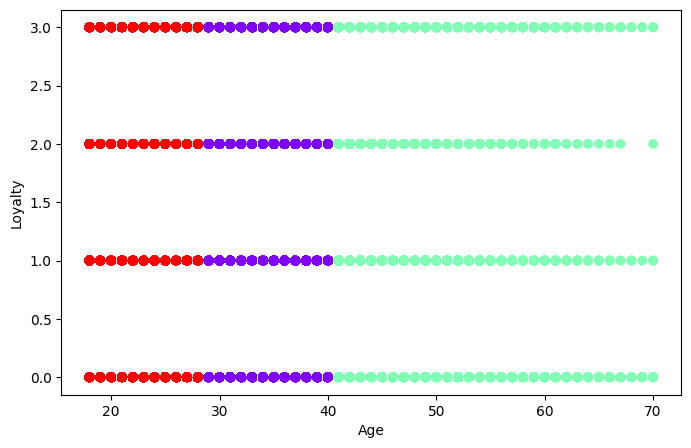

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'],df['loyalty_encoded'],c=df['clusters'],cmap='rainbow')
plt.xlabel('Age')
plt.ylabel('Loyalty')
plt.show()

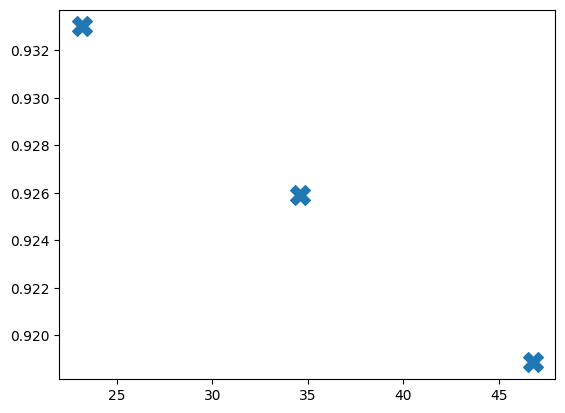

In [ ]:
plt.scatter( model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200, marker='X')

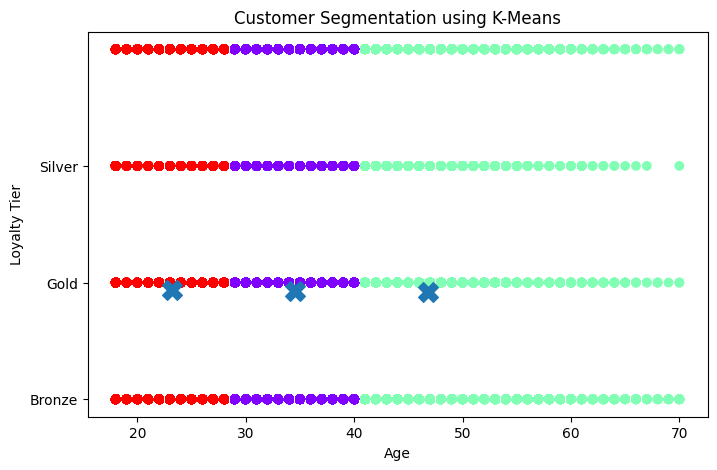

In [ ]:
from matplotlib.typing import ColourType
plt.figure(figsize=(8,5))
plt.scatter(df['age'],df['loyalty_encoded'],c=df['clusters'],cmap='rainbow')
plt.scatter( model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200, marker='X')
plt.xlabel('Age')
plt.ylabel('Loyalty Tier')
plt.yticks([0,1,2], ['Bronze','Gold','Silver'])
plt.title('Customer Segmentation using K-Means')
plt.show()

## DAY 4

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("sales.csv")

In [ ]:
encoder = LabelEncoder()
df['gender_encoded'] = encoder.fit_transform(df['gender'])
df['loyalty_encoded'] = encoder.fit_transform(df['loyalty_tier'])
df['country'] = encoder.fit_transform(df['country'])
df['channel_encoded'] = encoder.fit_transform(df['acquisition_channel'])

In [ ]:
x = df[[
    'age',
    'gender_encoded',
    'country',
    'channel_encoded'
]]

y = df['loyalty_encoded']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
predictions = model.predict(x_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy", accuracy)

matrix = confusion_matrix(
    y_test,
    predictions
)

print("Confusion Matrix")
print(matrix)

Accuracy 0.6004
Confusion Matrix
[[12008     0     0     0]
 [ 2383     0     0     0]
 [  636     0     0     0]
 [ 4973     0     0     0]]


## DAY 5

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [ ]:
df=pd.read_csv("customer_retail.csv")

In [ ]:
print(df.head())
df=df.dropna()

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [ ]:
df = df[['Quantity', 'UnitPrice', 'Country']]

In [ ]:
encoder = LabelEncoder()
df['Country_encoded'] = encoder.fit_transform(df['Country'])

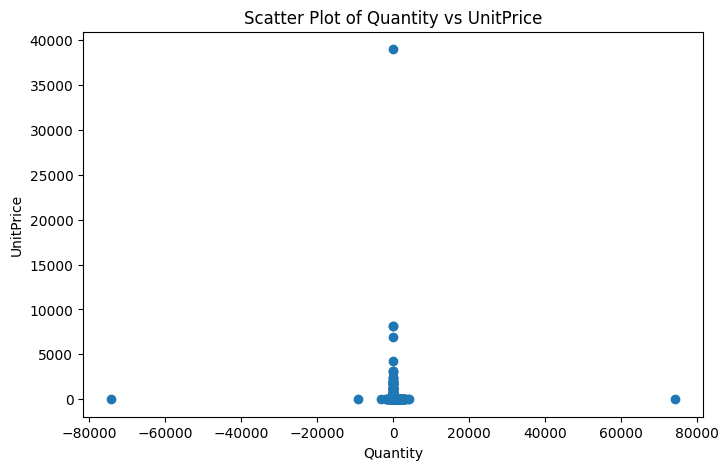

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['UnitPrice'])

plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter Plot of Quantity vs UnitPrice')

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
x = df[['Quantity', 'UnitPrice']]
y = df['Country_encoded']
scaler = StandardScaler()

x = scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Logistic Regression")
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)
y_pred = log_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\n\nDecision Tree")
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(confusion_matrix(y_test, y_pred))

print("\n\nKNN")
knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)
y_pred = knn_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(confusion_matrix(y_test, y_pred))

Logistic Regression
Accuracy: 0.8849178994997967
Confusion Matrix:
[[    0     0     0 ...     0   248     0]
 [    0     0     0 ...     0    45     0]
 [    0     0     0 ...     0     1     0]
 ...
 [    0     0     0 ...     0    13     0]
 [    0     0     0 ...     0 50066     0]
 [    0     0     0 ...     0    42     0]]


Decision Tree
Accuracy: 0.8855718754971101
[[   15     0     0 ...     0   220     0]
 [    0     0     0 ...     0    42     0]
 [    0     0     0 ...     0     1     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   36     0     0 ...     0 49931     0]
 [    0     0     0 ...     0    42     0]]


KNN
Accuracy: 0.8821075702140446
[[   14     0     0 ...     0   215     0]
 [    0     1     0 ...     0    43     0]
 [    0     0     0 ...     0     1     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   40     0     0 ...     0 49744     0]
 [    0     0     0 ...     0    42     0]]


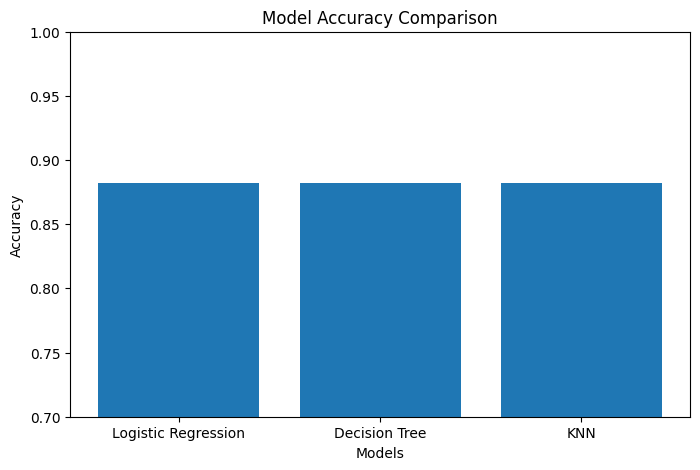

In [ ]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'KNN'
]

accuracies = [
    accuracy,
    accuracy,
    accuracy
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0.7, 1)
plt.show()